#Algoritmo de árvore de decisão aplicado à um problema de classificação

No projeto abaixo, vamos analisar um caso em que vou usar um modelo de Árvore de Decisão aplicada a um casso de classificação.

As principais métricas para avaliação de modelos de Classificação são:

- **Acurácia (Accuracy)**: percentual total de acertos (quantas previsões o modelo acertou).

- **Precisão (Precision)** entre as previsões positivas, quantas realmente eram positivas.

- **Sensibilidade (Recall)**: entre os casos realmente positivos, quantos o modelo conseguiu identificar.

- **Matriz de confusão**: mostra onde o modelo acertou e errou (verdadeiro positivo, falso positivo, etc.).


##Ilustração (caso particular): como fazer a leitura de algumas métricas

Abaixo segue um reve exemplo considerando uma tabela com variáveis que podem ser relevantes para determinar condições de venda de um dado tipo de produto em uma loja.

A coluna ***Produto vendido*** é chamada classe ou target. As demais variáveis são chamadas preditoras ou atributos.

| Gênero | Estado civil | Grau de instrução | ***Produto vendido*** |
| :--- | :--- | :--- | :--- |
| Feminino | Solteiro | Superior | ***A*** |
| Feminino | Casado | Ensino médio | ***B*** |
| Masculino | Viúvo | Mestrado | ***B*** |
| Feminino | Solteiro | Mestrado | ***B*** |
| Masculino | Solteiro | Superior | ***A*** |

A depender do modelo,não é possível trabalhar com strings, portanto é necessário uma conversão das variáveis para formato numérico, como exemplificado abaixo.

| Gênero | Estado civil | Grau de instrução | Produto vendido | ***Saída do modelo*** |
| :--- | :--- | :--- | :--- | :--- |
| 1 | 0 | 2 | 1 | 1 |
| 1 | 1 | 1 | ***0*** | ***1*** |
| 0 | 2 | 3 | 0 | 0 |
| 1 | 0 | 3 | 0 | 0 |
| 0 | 0 | 2 | 1 | 1 |

Matriz de confusão

Essa matriz nos ajuda a identificar quantos por cento de acerto tivemos, identificando quantos falsos positivos tivemos. Nas colunas de *Referência* indica os valores obtidos realmente, no nosso caso, quantos produtos foram realmente vendidos, enquanto as linhas com *Saída* trazem o valor retornado pelo código do modelo.


O preenchimento de cada célula segue a segunte lógica:

- Referência *i* x Saída *j*: Quando o valor de **referência** era *i*, quantas vezes o valor da **saída** era j?

|       | Referência 0 | Referência 1 |
|-------|-------------:|-------------:|
| Saída 0 | 2 | 0 |
| Saída 1 | 1 | 2 |

Para fazer a leitura dessa matriz, precisamos focar na diagonal, pois nela concentram-se os casos em que saída e resultado real estão de acordo. Para sabermos quanto erramos, basta olhar nas demais células. No presente caso, houve uma vez em que o resultado saiu 1, mas deveria ser zero (ou seja, o produto vendido foi B, mas a previsão indicou que o produto seria A).

Portanto, dizemos que o modelo teve 80% de acerto.

#Árvore de decisão

A seguir, vou desenvolver um algoritmo de Machine Learning para prever a tendência de uma pessoa desenvolver algum tipo de doença cardíaca com base em alguns fatores clínicos e laboratoriais.

Os dados são do "Heart Failure Prediction Dataset", retirados do site do Kaggle pelo link: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

## Pré-processamento

In [1]:
# vou instalar a biblioteca do kaggle só para puxar o dataset de forma mais rápida e fazer o tratamento aqui

!pip install -q kagglehub pandas

In [2]:
# comando para baixar o dataset

import kagglehub

path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print(path)

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
/kaggle/input/heart-failure-prediction


In [4]:
# ver quais arquivos existem na pasta
import os
os.listdir(path)

['heart.csv']

In [5]:
# Agora ler o CSV de fato e exibir primeiras linhas
import pandas as pd

df = pd.read_csv(f"{path}/heart.csv")
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
df.shape

(918, 12)

In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Checando quantos valores negativos há nesse df. Há 13 valores negativos na variável Oldpeak.

In [8]:
( df.select_dtypes(include='number') < 0 ).sum()

,0
Age,0
RestingBP,0
Cholesterol,0
FastingBS,0
MaxHR,0
Oldpeak,13
HeartDisease,0


Checando os tipos dos dados.

In [9]:
df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


Verifiquei se há nuloes e não há.

In [10]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


Verifiquei se há NAN e não há.

In [11]:
df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


#### Tranformando as variáveis categóricas NOMINAIS em variáveis categóricas ORDINAIS

Encontrando os valores únicos de cada coluna tipo object

In [12]:
df['ChestPainType'].unique() #df['ChestPainType'].value_counts()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

In [13]:
df['ChestPainType'].value_counts()

,count
ChestPainType,
ASY,496
NAP,203
ATA,173
TA,46


In [14]:
df['RestingECG'].unique()

array(['Normal', 'ST', 'LVH'], dtype=object)

In [15]:
df['ExerciseAngina'].unique()

array(['N', 'Y'], dtype=object)

In [16]:
df['ST_Slope'].unique()

array(['Up', 'Flat', 'Down'], dtype=object)

Traduzindo

In [17]:
df2 = pd.DataFrame.copy(df)

In [18]:
df2['Sex'] = df2['Sex'].replace( {'M': 0, 'F': 1})
df2['ChestPainType'] = df2['ChestPainType'].replace( {'ATA': 0, 'NAP': 1, 'ASY': 2, 'TA': 3})
df2['RestingECG'] = df2['RestingECG'].replace( {'Normal': 0, 'ST': 1, 'LVH': 2})
df2['ExerciseAngina'] = df2['ExerciseAngina'].replace( {'N': 0, 'Y': 1})
df2['ST_Slope'] = df2['ST_Slope'].replace( {'Up': 0, 'Flat': 1, 'Down': 2})

/tmp/ipykernel_462/2387216635.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2['Sex'] = df2['Sex'].replace( {'M': 0, 'F': 1})
/tmp/ipykernel_462/2387216635.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2['ChestPainType'] = df2['ChestPainType'].replace( {'ATA': 0, 'NAP': 1, 'ASY': 2, 'TA': 3})
/tmp/ipykernel_462/2387216635.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-

In [19]:
df2.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140,289,0,0,172,0,0.0,0,0
1,49,1,1,160,180,0,0,156,0,1.0,1,1
2,37,0,0,130,283,0,1,98,0,0.0,0,0
3,48,1,2,138,214,0,0,108,1,1.5,1,1
4,54,0,1,150,195,0,0,122,0,0.0,0,0


In [20]:
df2.dtypes

,0
Age,int64
Sex,int64
ChestPainType,int64
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,int64
MaxHR,int64
ExerciseAngina,int64
Oldpeak,float64


Agora com as variáveis rotuladas, verifiquei que todas são tipo int, exceto Oldpeak, que é tipo float.

##Legenda das colunas

Aqui está o significado de cada coluna do conjunto de dados:

* **Age**: idade do paciente [anos]
* **Sex**: sexo do paciente [M: Masculino, F: Feminino]
* **ChestPainType**: tipo de dor torácica [TA: Angina Típica, ATA: Angina Atípica, NAP: Dor Não Anginosa, ASY: Assintomático]
* **RestingBP**: pressão arterial em repouso [mm Hg]
* **Cholesterol**: colesterol sérico [mm/dl]
* **FastingBS**: açúcar no sangue em jejum [1: se FastingBS > 120 mg/dl, 0: caso contrário]
* **RestingECG**: resultados do eletrocardiograma em repouso [Normal: Normal, ST: com anormalidade na onda ST-T (inversões da onda T e/ou elevação ou depressão de ST > 0,05 mV), LVH: mostrando hipertrofia ventricular esquerda provável ou definida pelos critérios de Estes]
* **MaxHR**: frequência cardíaca máxima atingida [Valor numérico entre 60 e 202]
* **ExerciseAngina**: angina induzida por exercício [Y: Sim, N: Não]
* **Oldpeak**: oldpeak = ST [Valor numérico medido em depressão]
* **ST_Slope**: a inclinação do segmento ST no pico do exercício [Up: ascendente, Flat: plano, Down: descendente]
* **HeartDisease**: classe de saída [1: doença cardíaca, 0: Normal]

##Previsores (atributos) e Target (alvo)

In [21]:
df2.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140,289,0,0,172,0,0.0,0,0
1,49,1,1,160,180,0,0,156,0,1.0,1,1
2,37,0,0,130,283,0,1,98,0,0.0,0,0
3,48,1,2,138,214,0,0,108,1,1.5,1,1
4,54,0,1,150,195,0,0,122,0,0.0,0,0


Aqui a coluna Alvo será a a HeartDisease, enquanto as demais colunas serão as previsoras.

In [22]:
import numpy as np

In [23]:
previsores = df2.iloc[:, 0:11].values # aqui indicamos que se considere todas as linhas (:) das colunas 0 até a 10 (0:11)
previsores

array([[40. ,  0. ,  0. , ...,  0. ,  0. ,  0. ],
       [49. ,  1. ,  1. , ...,  0. ,  1. ,  1. ],
       [37. ,  0. ,  0. , ...,  0. ,  0. ,  0. ],
       ...,
       [57. ,  0. ,  2. , ...,  1. ,  1.2,  1. ],
       [57. ,  1. ,  0. , ...,  0. ,  0. ,  1. ],
       [38. ,  0. ,  1. , ...,  0. ,  0. ,  0. ]])

In [24]:
previsores.shape

(918, 11)

In [25]:
alvo = df2.iloc[:, 11].values # OU alvo = df2['HeartDisease'].values
alvo

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,

In [26]:
alvo.shape

(918,)

In [27]:
alvo.dtype

dtype('int64')

## Divisão entre base de treino e teste

Aqui vamos usar a função `train_test_split` da biblioteca `sklearn`.

Essa função pode ter os seguintes parâmetros:

Parâmetros train_test_split:

- arrays: nomes dos atributos previsores e alvo.
- test_size: tamanho, em porcentagem, dos dados de teste; default é none.
- train_size: tamanho, em porcentagem, dos dados de treinamento; default é none.
- random_state: nomeação de um estado aleatório; garante reprodutibilidade.
- shuffle: embaralhamento dos dados aleatórios. Associado com o random_state ocorre o mesmo embaralhamento sempre. Default é True.
- stratify: possibilidade de dividir os dados de forma estratificada. Default é None (nesse caso, é mantido a proporção, isto é, se tem 30% de zeros e 70% de 1 no dataframe, na separação em treinamento e teste essa proporção será preservada).

Aqui vamos usar só 4 parâmetros.

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
x_treino, x_teste, y_treino, y_teste = train_test_split(previsores, alvo, test_size = 0.3, random_state = 0)
# caso queiramos ver a carinha de cada uma dessas variáveis, podemos printar, como abaixo
y_treino.shape #x_treino.shape, y_treino.shape, x_teste.shape

(642,)

Aqui as variáveis `x` se referem às variáveis preditoras e `y` ao alvo:

- `x_treino` = `previsores_treino`
- `y_treino` = `alvo_treino`
- `x_teste` = `previsores_teste`
- `y_teste` = `alvo_teste`

Vou adicionar mais um bloco que é para garantir que a variável target (tanto treino quanto teste) seja tipo `int`, já que, para esse modelo de classificação, essa variável precisa ser tipo inteira.

In [31]:
y_treino.dtype

dtype('int64')

In [32]:
y_teste.dtype

dtype('int64')

In [33]:
x_treino.dtype

dtype('float64')

In [34]:
x_teste.dtype

dtype('float64')

## Aplicando o modelo de árvore de decisão

Aqui vou precisar importar mais algumas funções, em especial a `DecisionTreeClassifier`.

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

Alguns dos parâmetros que a `DecisionTreeClassifier` aceita são:

- criterion: 'entropy': que fala da importância dos nós.
- random_state: reprodutibilidade; garantir que, sempre que esse código rodar, ele vai iniciar-se no mesmo ponto.
- max_depth: diz respeito à profundidade da árvore.

In [36]:
# Criando a árvore; instanciando a classe DecisionTreeClassifier
arvore = DecisionTreeClassifier(criterion = 'entropy', random_state = 0, max_depth = 3)
arvore

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

Uma observação importante: é necessário seguir a ordem `x_treino`, `x_teste`, `y_treino`, `y_teste` na hora de instanciar a classe da árvore de decisão, pois se invertermos ao menos uma das variáveis pode dar erro de compatibilidade entre número de colunas entre `x`e `y`.

In [37]:
y_treino.dtype

dtype('int64')

In [38]:
y_teste.dtype

dtype('int64')

In [39]:
x_treino.dtype

dtype('float64')

In [40]:
x_teste.dtype

dtype('float64')

Dentro dos modelos de Machine Learning, quando aplicamos o  `.fit`significa que estamos aplicando o modelo ao conjunto de dados.

In [41]:
_arvore = arvore.fit(x_treino, y_treino)

[Text(0.5, 0.875, 'x[10] <= 0.5\nentropy = 0.996\nsamples = 642\nvalue = [297, 345]'),
 Text(0.25, 0.625, 'x[2] <= 1.5\nentropy = 0.636\nsamples = 280\nvalue = [235, 45]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[0] <= 56.5\nentropy = 0.239\nsamples = 178\nvalue = [171, 7]'),
 Text(0.0625, 0.125, 'entropy = 0.107\nsamples = 142\nvalue = [140, 2]'),
 Text(0.1875, 0.125, 'entropy = 0.581\nsamples = 36\nvalue = [31, 5]'),
 Text(0.375, 0.375, 'x[8] <= 0.5\nentropy = 0.953\nsamples = 102\nvalue = [64, 38]'),
 Text(0.3125, 0.125, 'entropy = 0.811\nsamples = 72\nvalue = [54, 18]'),
 Text(0.4375, 0.125, 'entropy = 0.918\nsamples = 30\nvalue = [10, 20]'),
 Text(0.75, 0.625, 'x[7] <= 151.0\nentropy = 0.661\nsamples = 362\nvalue = [62, 300]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[1] <= 0.5\nentropy = 0.505\nsamples = 304\nvalue = [34, 270]'),
 Text(0.5625, 0.125, 'entropy = 0.401\nsamples = 264\nvalue = [21, 243]'),
 Text(0.6875, 0.125, 'entropy = 0.91\nsamples = 40\

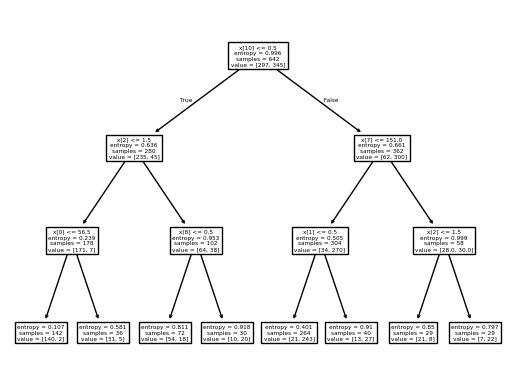

In [45]:
tree.plot_tree(_arvore)

Para aumentar o tamanho na árvore, preciso importar o `matplotlib` porque o parâmetros que entra no `plot_tree` que ajusta o tamanho da figura está nessa biblioteca.

In [46]:
import matplotlib.pyplot as plt

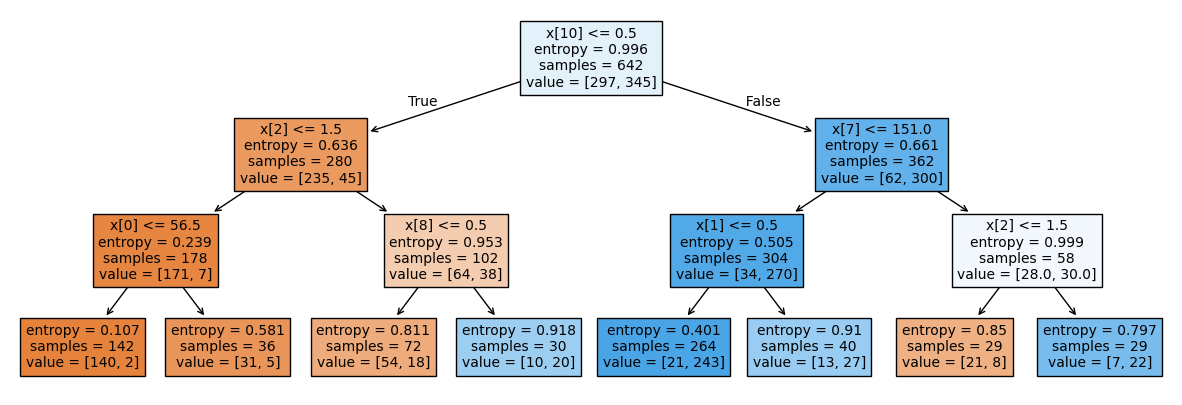

In [49]:
plt.figure(figsize = (15, 5))

tree.plot_tree(_arvore, fontsize = 10, filled = True)

plt.show()

## Previsão dos dados de teste

Nesse momento vou testar a validade do modelo aplicando-o às entradas de teste.

Para issi, vamos usar a função `.predict()` aplicada aos valores que ainda não foram vistos pelo modelo, ou seja, ao `x_teste`.

In [52]:
resultado_previsores_arvore = arvore.predict(x_teste)
resultado_previsores_arvore

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

Para vermos se os valores da previsão batem com as respostas reais, podemos comparar o array de cima (saída com modelo) com os resultados reais do conjunto de dados alvo de teste, ou seja, o `y_teste`, abaixo.

In [53]:
y_teste

array([1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

Note já que, dentre os 4 primeiros resultados, o segundo resuntado da previsão, que foi 1, não bateu com o segundo resultado real do `y_teste`, que foi 0. Isso **é um problema**, pois, afinal, estamos falando sobre a possibilidade de uma pessoa ter ou não ter um AVC.

## Acurácia e Matriz de Confusão

Para evitar fazer essa comparação manualmente (olhando resultado por resultado), podemos usar a **Matriz de confusão**, que veremos mais adiante.

Também vamos calcular a métrica da **Acurácia**. Para exibir essas informações, vamos importar as seguintes funções do `sklearn`.

In [54]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [58]:
# acurácia
acuracia = round(accuracy_score(y_teste, resultado_previsores_arvore) * 100, 2)

print(f"Acurácia: {acuracia}")

Acurácia: 80.43


A acurácia foi de 80,43%.

In [60]:
# matriz de confusão
confusion_matrix(y_teste, resultado_previsores_arvore)

array([[ 87,  26],
       [ 28, 135]])

Os resultados da matriz de confusão indicam que:

- das vezes em que o valor real é 0 e o valor predito é 0, tivemos 87 acertos.
- das vezes em que o valor real é 1 e o valor predito é 1, tivemos 135 acertos.
- das vezes em que o valor real é 0 e o valor predito é 1, tivemos 28 casos.
- das vezes em que o valor real é 1 e o valor predito é 0, tivemos 26 casos.

Vou ajustar melhor a matriz para maior legibilidade.

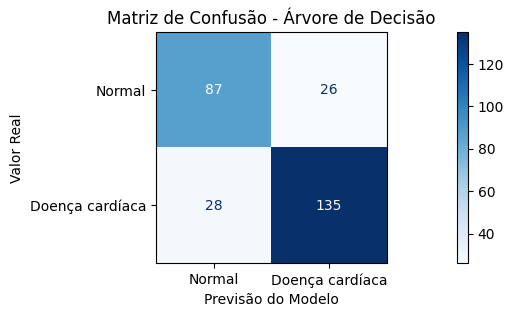

In [66]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_teste, resultado_previsores_arvore)

# Configura a exibição com títulos
# O display_labels deve ser ajustado para o que cada classe significa (0=Normal, 1=Doença cardíaca)
fig, ax = plt.subplots(figsize=(18, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Doença cardíaca'])

# estilo
disp.plot(ax=ax, cmap='Blues', values_format='d')

ax.set_title('Matriz de Confusão - Árvore de Decisão')
ax.set_xlabel('Previsão do Modelo')
ax.set_ylabel('Valor Real')

plt.show()

## Balanço das métricas

Com a função `classification_report` podemos ver um resumo geral de todas as métricas importantes para essa análise, incluindo a acurácia.

- A métrica Precisão é indicada quando o objetivo é evitar alarmes falsos (evitar exames desnecessários).

- A métrica Recall é indicada quando o objetivo é não deixar passar nenhum doente (um hospital quer priorizar a detecção).


- A métrica F1-score é a média harmônica entre a Precisão e o Recall. É a métrica mais equilibrada para avaliar se o modelo é bom: se o F1-score está alto, o modelo está performando bem para ambas as necessidades. Caso contrário, a performance é ruim.

- A coluna Support é o tamanho da sua base de prova, ou seja, indica o número de dados que temos de pessoas normais (saudáveis) e o de pessoas com doença cardíaca (no nosso caso abaixo).

A acurácia entra no conjunto das métricas que envolvem médias, ao lado de Macr Avg e Weighted Avg.

- A métrica de Acurácia indica a porcentagem de acertos totais do modelo. É um cálculo global de todos os seus acertos: ela já é o resultado final da divisão: total de acertos / total de amostras.

- A Macro Avg calcula a média aritmética das métricas, tratando todas as classes como igualmente importantes, independente de quantas amostras cada uma tem.

- A Weighted Avg calcula a média ponderada, dando mais peso para a classe que aparece mais vezes no support.

In [72]:
outras_metricas = classification_report(y_teste, resultado_previsores_arvore)
print(outras_metricas)

              precision    recall  f1-score   support

           0       0.76      0.77      0.76       113
           1       0.84      0.83      0.83       163

    accuracy                           0.80       276
   macro avg       0.80      0.80      0.80       276
weighted avg       0.80      0.80      0.80       276



Interpretando os resultados

- **Precisão**

- - Caso 0 (0.76): Quando o modelo diz que um paciente é "normal", ele acerta essa previsão em 76% dos casos. Em 24% dos casos, ele diagnosticou alguém como "normal", na verdade, a pessoa tinha a doença (falso positivo).

- - Caso 1 (0.84): Quando o modelo diz que um paciente tem "doença cardíaca", ele acerta essa previsão em 84% dos casos. Em 26% dos casos, ele indicou que o paciente tinha "doença cardíaca" quando, na verdade, a pessoa estava saudável (falso negativo).

- **Recall**

- - Caso 0 (0.77): Dos pacientes que realmente são "normais" (saudáveis), o modelo conseguiu identificar corretamente 77% deles.

- - Caso 1 (0.83): Dos pacientes que realmente estão com "doença cardíaca", o modelo conseguiu identificar 83% deles. Este é um valor muito positivo para uma aplicação médica, pois significa que a maioria dos doentes é detectada.

- **F1-Score**

- - Caso 0 (0.76): É o equilíbrio entre a precisão e o recall da classe de pessoas "normais". Como ambos são similares (0.76 e 0.77), o modelo mantém um desempenho estável para prever quem é saudável.

- - Caso 1 (0.83): O equilíbrio do modelo para a classe de doentes é excelente (0.83), indicando que o modelo é robusto ao identificar quem realmente precisa de atenção médica.

Sendo o Support a contagem de amostras reais em cada classe, vemos que temos 113 casos de "Normal" (0) e 163 casos de "Doença" (1) no conjunto de teste.

Sendo a Acurácia o total de acertos pelo total da amostra, vemos que tivemos 80% de acerto nos dados.

Como a Macro Avg calcula a média aritmética das métricas, tratando todas as classes como igualmente importantes, independente de quantas amostras cada uma tem, vemos que ela também é de 80% em todos os casos.

Por fim, como a Weighted Avg calcula a média ponderada, dando mais peso para a classe que aparece mais vezes no support, temos mais casos de doença (163) do que de normal (113); essa média é um pouco mais influenciada pela performance na classe 1.

**Conclusão**

O modelo é bastante sólido. Ele apresentou uma performance muito equilibrada entre as duas classes.
